In [25]:
import re

import catboost
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import seaborn as sns
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split


In [2]:
master_df = pd.read_csv('../data/csv/master_df.csv')
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        220688 non-null  str    
 1   href                      220688 non-null  str    
 2   price                     220688 non-null  int64  
 3   title                     220688 non-null  str    
 4   status                    220688 non-null  str    
 5   content                   220688 non-null  str    
 6   createdAt                 220688 non-null  str    
 7   boostedAt                 220688 non-null  str    
 8   user_dbId                 220688 non-null  int64  
 9   user_nickname             220688 non-null  str    
 10  region_name_from_article  220688 non-null  str    
 11  region_id                 220688 non-null  int64  
 12  region_name               220688 non-null  str    
 13  region_in                 220688 non-null  str    
 14 

In [3]:
cols = [
    'id', 'price', 'title', 'status', 'content', 'createdAt',
    'boostedAt', 'region_name', 'crawledAt', 'favoriteCount',
    'chatCount', 'viewCount', 'sellerTemperature', 'imageCount',
    'brandName', 'label', 'coarse_label', 'days_since_created',
    'created_hour', 'created_dayofweek', 'is_boosted', 'title_len',
    'content_len', 'days_elapsed'
]

In [5]:
### feature engineering ###
df = master_df[cols]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  220688 non-null  str    
 1   price               220688 non-null  int64  
 2   title               220688 non-null  str    
 3   status              220688 non-null  str    
 4   content             220688 non-null  str    
 5   createdAt           220688 non-null  str    
 6   boostedAt           220688 non-null  str    
 7   region_name         220688 non-null  str    
 8   crawledAt           220688 non-null  str    
 9   favoriteCount       220688 non-null  int64  
 10  chatCount           220688 non-null  int64  
 11  viewCount           220688 non-null  int64  
 12  sellerTemperature   220688 non-null  float64
 13  imageCount          220688 non-null  int64  
 14  brandName           220688 non-null  str    
 15  label               220688 non-null  str    


In [7]:
df.to_csv('../data/csv/parse_brands.csv')

In [9]:
df = pd.read_csv('../data/csv/parse_brands_enriched.csv', index_col=0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220688 entries, 0 to 220687
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  220688 non-null  str    
 1   price               220688 non-null  int64  
 2   title               220688 non-null  str    
 3   status              220688 non-null  str    
 4   content             220688 non-null  str    
 5   createdAt           220688 non-null  str    
 6   boostedAt           220688 non-null  str    
 7   region_name         220688 non-null  str    
 8   crawledAt           220688 non-null  str    
 9   favoriteCount       220688 non-null  int64  
 10  chatCount           220688 non-null  int64  
 11  viewCount           220688 non-null  int64  
 12  sellerTemperature   220688 non-null  float64
 13  imageCount          220688 non-null  int64  
 14  brandName           220688 non-null  str    
 15  label               220688 non-null  str    


In [38]:
# 7일 이내 올라온 게시글 중에 가격이 1이고 판매된 데이터 필터링
filtered_df = df[(df['price'] == 1) & (df['status'] != 'Ongoing') & (df['days_elapsed'] <= 7)]

# 개수 확인
count = len(filtered_df)
print(count)

# 7일 이내 올라온 게시글 중에 가격이 1이고 판매된 데이터 필터링
filtered_df = df[(df['price'] == 1) & (df['status'] != 'Ongoing') & (df['days_elapsed'] > 7)]

# 개수 확인
count = len(filtered_df)
print(count)
## 1. 데이터 셋에서 판매중인 1원 상품 수는 33개, 판매 완료된 1원인 상품 수가 21 + 2223개이기 때문에
##    데이터중 노이즈라고 보고 빼는게 맞는것 같다.
## 2. 7일이 지난 판매중인 글 중에서도 33개 있기 때문에 완료돼서 바꾼 사람도 있고
##    나눔을 그냥 1원 받고 올린 사람도 있는것 같다.
## feedback. 향후에 1원인 데이터들을 제대로 카테고리별로 보고 뺄지 안뺄지 판단하면 될 듯 하다.

21
2223


In [39]:
# price가 1이 아닌 로우만 선택하여 저장
df = df[df['price'] != 1]

In [40]:
df['favorite_per_view'] = df['favoriteCount'] / (df['viewCount'] + 1)
df['chat_per_view'] = df['chatCount'] / (df['viewCount'] + 1)

In [41]:
brand_median_price = df.groupby('brandName')['price'].transform('median')
label_median_price = df.groupby('label')['price'].transform('median')

df['price_ratio_to_brand'] = df['price'] / (brand_median_price + 1)
df['price_ratio_to_label'] = df['price'] / (label_median_price + 1)

In [49]:
n_days = 7  # 예: 7일 이내 판매 여부

# 2. Target 변수 생성 함수
def make_target(row, n):
    # status 컬럼의 '거래완료'를 의미하는 정확한 텍스트 확인 필요 (예: 'Completed', 'Sold' 등)
    is_sold = row['status'] != 'Ongoing'  # 혹은 status_detail 사용

    if is_sold and row['days_elapsed'] <= n:
        return 1  # n일 이내 판매됨
    elif not is_sold and row['days_elapsed'] > n:
        return 0  # n일이 지났는데도 안 팔림
    else:
        return np.nan  # 아직 n일이 안 지났는데 안 팔린 상태 (보류)


df['target_n_days'] = df.apply(lambda x: make_target(x, n_days), axis=1)
# 판별 불가능한(보류된) 데이터 학습에서 제외
df = df.dropna(subset=['target_n_days']).copy()

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 131788 entries, 0 to 220687
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    131788 non-null  str    
 1   price                 131788 non-null  int64  
 2   title                 131788 non-null  str    
 3   status                131788 non-null  str    
 4   content               131788 non-null  str    
 5   createdAt             131788 non-null  str    
 6   boostedAt             131788 non-null  str    
 7   region_name           131788 non-null  str    
 8   crawledAt             131788 non-null  str    
 9   favoriteCount         131788 non-null  int64  
 10  chatCount             131788 non-null  int64  
 11  viewCount             131788 non-null  int64  
 12  sellerTemperature     131788 non-null  float64
 13  imageCount            131788 non-null  int64  
 14  brandName             131788 non-null  str    
 15  label           

In [51]:
cols_to_drop = [
    'id', 'status', 'createdAt', 'boostedAt', 'crawledAt', 'days_since_created', 
    'created_hour', 'created_dayofweek'
]

In [52]:
clean_df = df.drop(cols_to_drop, axis=1)
clean_df.info()

<class 'pandas.DataFrame'>
Index: 131788 entries, 0 to 220687
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   price                 131788 non-null  int64  
 1   title                 131788 non-null  str    
 2   content               131788 non-null  str    
 3   region_name           131788 non-null  str    
 4   favoriteCount         131788 non-null  int64  
 5   chatCount             131788 non-null  int64  
 6   viewCount             131788 non-null  int64  
 7   sellerTemperature     131788 non-null  float64
 8   imageCount            131788 non-null  int64  
 9   brandName             131788 non-null  str    
 10  label                 131788 non-null  str    
 11  coarse_label          131788 non-null  str    
 12  is_boosted            131788 non-null  int64  
 13  title_len             131788 non-null  int64  
 14  content_len           131788 non-null  int64  
 15  days_elapsed    

In [12]:
clean_df = pd.read_csv('../data/csv/clean_df2.csv', index_col=0)

In [27]:
sell_features = [
    'price',
    'title',
    'content',
    'region_name',
    'sellerTemperature',
    'brandName',
    'label',
    'coarse_label',
    'title_len',
    'content_len',
    'price_ratio_to_brand',
]

In [36]:
X = clean_df[sell_features]
y = clean_df['target_n_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = ['region_name', 'brandName', 'label', 'coarse_label']
text_features = ['title', 'content']

# ★ Optuna 속도 최적화를 위해 Pool 객체 미리 생성 ★
train_pool = Pool(
    X_train, y_train, cat_features=cat_features, text_features=text_features
)
valid_pool = Pool(
    X_test, y_test, cat_features=cat_features, text_features=text_features
)

In [29]:
# ==========================================
# 2. Optuna Objective 함수 정의
# ==========================================

def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1500),  # 학습 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int(
            'depth', 4, 8
        ),  # 텍스트 모델은 메모리를 많이 쓰므로 최대 8 권장
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),  # 정규화
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),  # 과적합 방지
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        # 고정 파라미터
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 0,  # 튜닝 중에는 로그 출력 끄기
    }

    model = CatBoostClassifier(**param)

    # 모델 학습 (Early Stopping 적용)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    # 검증셋에서 가장 높았던 PR-AUC 점수를 반환
    proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)

    return pr_auc


# ==========================================
# 3. Optuna Study 실행 (탐색 시작)
# ==========================================
print('🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...')
study = optuna.create_study(direction='maximize')  # AUC는 높을수록 좋으므로 maximize
study.optimize(
    objective, n_trials=100
)  # 우선 30번만 시도 (시간에 따라 50~100번으로 늘려보세요)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

# ==========================================
# 4. 찾은 최적 파라미터로 최종 모델 학습 및 평가
# ==========================================
print('\n🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...')
best_params = study.best_params

# 고정 파라미터 다시 추가
best_params.update(
    {
        'eval_metric': 'Logloss',
        'random_seed': 42,
        #'auto_class_weights': 'SqrtBalanced',
        'task_type': 'GPU',
        'verbose': 50,  # 최종 학습이므로 로그 출력
    }
)

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

# 최종 평가
preds = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

print('\n✅ [최종 모델 평가 지표]')
print(classification_report(y_test, preds))
print(f'PR-AUC: {average_precision_score(y_test, proba):.4f}')

# ==========================================
# 5. Permutation Importance 계산 (최종 1회)
# ==========================================
print('\n📊 Permutation Importance 계산 중... (시간이 조금 소요됩니다)')
X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

result = permutation_importance(
    final_model,
    X_test_sample,  # Pool이 아닌 DataFrame 자체를 넣어야 사이킷런과 호환됨
    y_test_sample,
    n_repeats=6,
    random_state=42,
    scoring='average_precision',
    n_jobs=-1,
)

perm_imp_df = pd.DataFrame(
    {
        'Feature': X_test_sample.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std,
    }
).sort_values(by='Importance', ascending=False)

print('\n[Permutation Importance 결과]')
print(perm_imp_df)

# 최종 모델 저장 (선택)
final_model.save_model("daangn_sell_predictor_new.cbm")

[I 2026-03-10 14:50:58,023] A new study created in memory with name: no-name-e5ab20bb-7591-45e3-ae83-74a0bb6485da


🚀 Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-10 14:51:08,303] Trial 0 finished with value: 0.09381939798014662 and parameters: {'iterations': 529, 'learning_rate': 0.012803761691563671, 'depth': 8, 'l2_leaf_reg': 0.0206948907028458, 'random_strength': 0.3632629024989631, 'bagging_temperature': 0.6203084797242521}. Best is trial 0 with value: 0.09381939798014662.
[I 2026-03-10 14:51:11,218] Trial 1 finished with value: 0.042460187756960116 and parameters: {'iterations': 1033, 'learning_rate': 0.11057303283548017, 'depth': 5, 'l2_leaf_reg': 0.0021944482687050316, 'random_strength': 0.004923140192759819, 'bagging_temperature': 0.4098142047179092}. Best is trial 0 with value: 0.09381939798014662.
[I 2026-03-10 14:51:15,902] Trial 2 finished with value: 0.1403995248680446 and parameters: {'iterations': 1231, 'learning_rate': 0.14558309331661218, 'depth': 6, 'l2_leaf_reg': 0.053359837508848915, 'random_strength': 9.600910599544706, 'bagging_temperature': 0.013180975447977472}. Best is trial 2 with value: 0.1403995248680446.



🏆 [Best Trial]
최고 PR-AUC 점수: 0.1618
최적의 파라미터:
  iterations: 1469
  learning_rate: 0.04102833835375181
  depth: 7
  l2_leaf_reg: 0.9152519041277306
  random_strength: 8.03577948977175
  bagging_temperature: 0.373116929765564

🔥 찾은 최적의 파라미터로 최종 모델을 학습합니다...
0:	learn: 0.6070848	test: 0.6069031	best: 0.6069031 (0)	total: 9.15ms	remaining: 13.4s
50:	learn: 0.0614818	test: 0.0614420	best: 0.0614420 (50)	total: 532ms	remaining: 14.8s
100:	learn: 0.0580642	test: 0.0586188	best: 0.0586188 (100)	total: 1.07s	remaining: 14.6s
150:	learn: 0.0566309	test: 0.0575482	best: 0.0575482 (150)	total: 1.6s	remaining: 13.9s
200:	learn: 0.0553487	test: 0.0567343	best: 0.0567343 (200)	total: 2.13s	remaining: 13.5s
250:	learn: 0.0543397	test: 0.0561660	best: 0.0561660 (250)	total: 2.64s	remaining: 12.8s
300:	learn: 0.0533865	test: 0.0557977	best: 0.0557969 (299)	total: 3.14s	remaining: 12.2s
350:	learn: 0.0522313	test: 0.0554291	best: 0.0554291 (350)	total: 3.58s	remaining: 11.4s
400:	learn: 0.0510681	test: 0

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.05      | 0.2410    | 0.2248 | 0.2326
0.10      | 0.3545    | 0.1309 | 0.1912
0.15      | 0.4923    | 0.1074 | 0.1763
0.20      | 0.6486    | 0.0805 | 0.1433
0.25      | 0.7500    | 0.0705 | 0.1288
0.30      | 0.7826    | 0.0604 | 0.1121
0.35      | 0.8824    | 0.0503 | 0.0952
0.40      | 0.9167    | 0.0369 | 0.0710
0.45      | 1.0000    | 0.0336 | 0.0649
0.50      | 1.0000    | 0.0235 | 0.0459
0.55      | 1.0000    | 0.0235 | 0.0459
0.60      | 1.0000    | 0.0235 | 0.0459
0.65      | 1.0000    | 0.0168 | 0.0330
0.70      | 1.0000    | 0.0067 | 0.0133
0.75      | 1.0000    | 0.0067 | 0.0133
0.80      | 1.0000    | 0.0034 | 0.0067
0.85      | 0.0000    | 0.0000 | 0.0000
0.90      | 0.0000    | 0.0000 | 0.0000

최적의 Threshold: 0.05 (최고 F1-score: 0.2326)
🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.0505
👉 Best F1-Score  : 0.2347

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-s

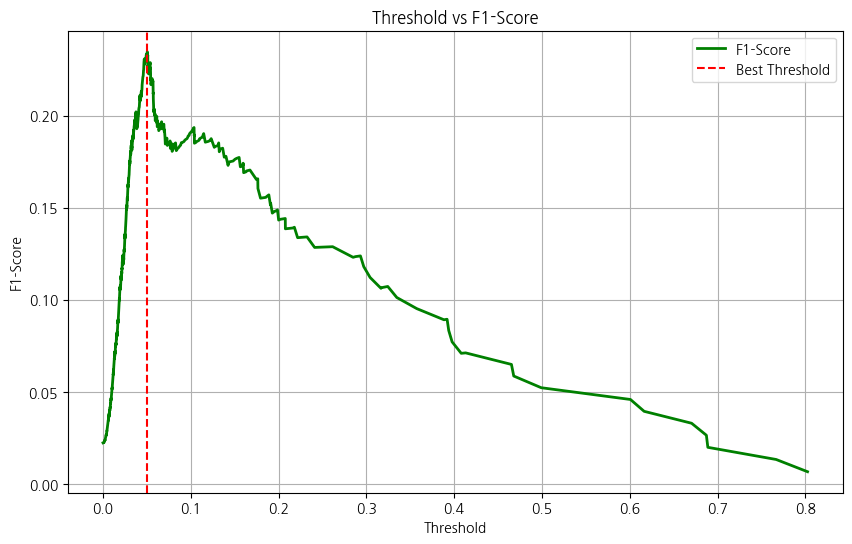

In [33]:
# 1. 1(팔림)이 될 '확률(Probability)'만 따로 추출
proba = final_model.predict_proba(X_test)[:, 1]

# 2. 다양한 임계값(Threshold) 테스트
thresholds = np.arange(0.05, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print('Threshold | Precision | Recall | F1-Score')
print('-' * 45)
for thresh in thresholds:
    # 확률이 thresh 이상일 때만 1로 예측
    custom_preds = (proba >= thresh).astype(int)

    p = precision_score(y_test, custom_preds, zero_division=0)
    r = recall_score(y_test, custom_preds)
    f1 = f1_score(y_test, custom_preds)

    print(f'{thresh:.2f}      | {p:.4f}    | {r:.4f} | {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\n최적의 Threshold: {best_thresh:.2f} (최고 F1-score: {best_f1:.4f})')


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_test는 테스트 데이터의 실제 정답)
y_proba = final_model.predict_proba(X_test)[:, 1]
best_threshold = find_optimal_threshold(y_test, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_test, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_test, y_proba)

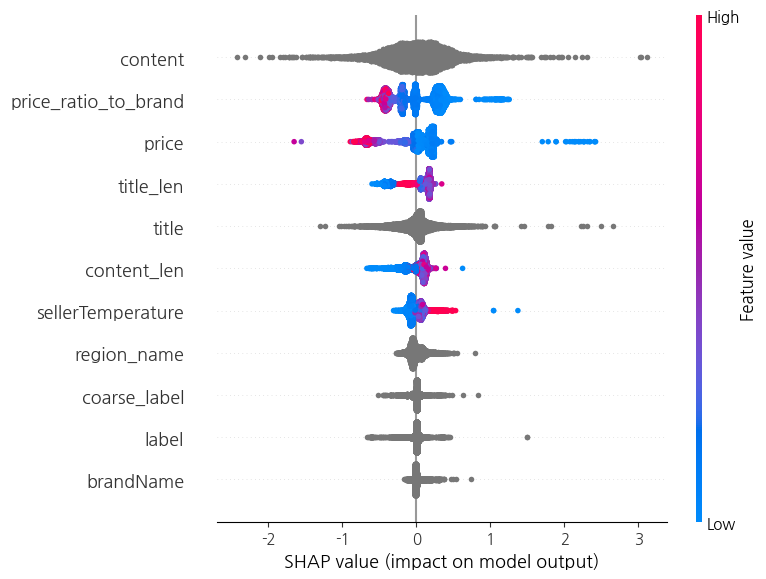

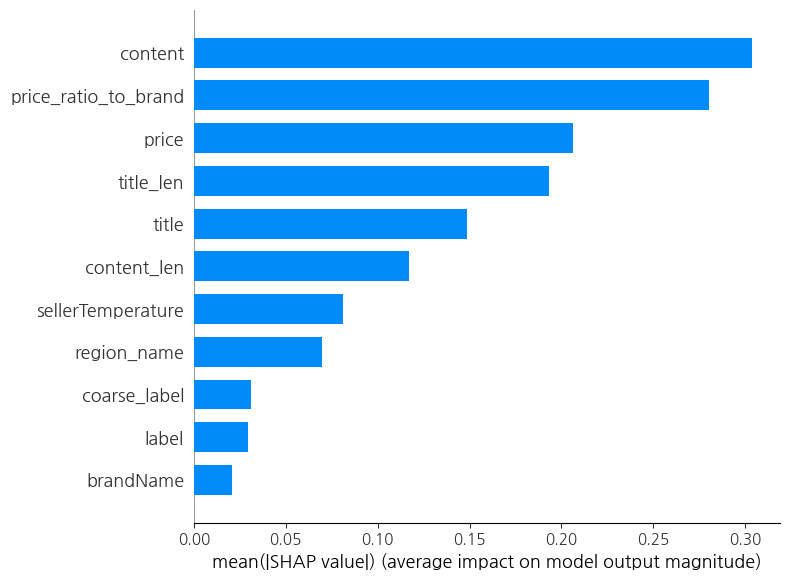

In [37]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 텍스트 피처가 있으므로 Pool 형태로 묶어서 에러 방지 (필요 시)
sample_pool = Pool(
    X_test_sample, y_test_sample, cat_features=cat_features, text_features=text_features
)

# 1. 트리 모델용 초고속 SHAP Explainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. Test Set 일부에 대한 SHAP 값 계산 (속도가 빨라 더 많이 넣어도 됩니다)
X_test_sample = X_test.sample(n=10000, random_state=42)
# shap_values = explainer(X_test_sample)
shap_values = explainer.shap_values(sample_pool)

# 3. 전체 Feature Importance 시각화 (요약 플롯)
# 피처가 예측값(판매 확률)을 높이는 데 기여했는지 낮추는 데 기여했는지 색상으로 보여줍니다.
shap.summary_plot(shap_values, X_test_sample)

# 4. 단순 막대 그래프로 중요도 순위만 보고 싶을 때
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

판매 아이템: 남자 POLO 신형 셔츠
본문 내용: 105
가슴58

옷수집가라
옷이워낙많아서
드레스룸
정리중입니다
컨디션좋은아이들로
판매중이고
전부 정품만
판매합니다!!!

개인사정으로
택배거래만
합니다!!!
로젠사용합니다
택배비...
실제 7일 내 판매 여부: ✅ 팔림
🔥 AI 예측 판매 확률: 80.25%



/home/wanted-1/WantedPotenUp/personal/seunghun/pj02_Daangn-marke/.venv/lib/python3.12/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/home/wanted-1/WantedPotenUp/personal/seunghun/pj02_Daangn-marke/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


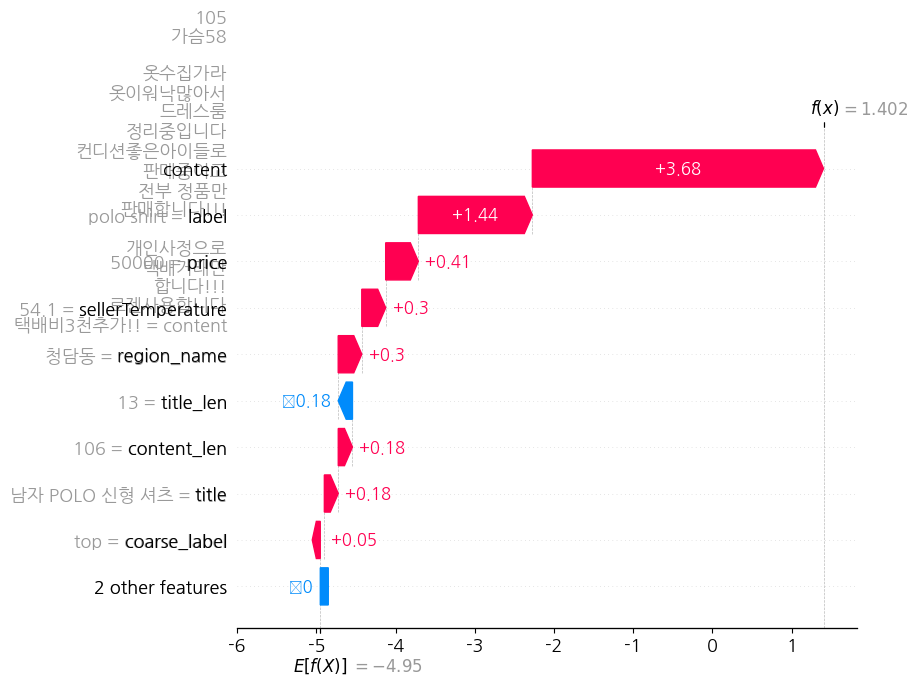

In [38]:
# 맑은 고딕(Malgun Gothic) -> 나눔고딕(NanumGothic)으로 변경
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. SHAP TreeExplainer 선언
explainer = shap.TreeExplainer(final_model)

# 2. 분석하고 싶은 데이터 딱 1개 고르기
best_idx = np.argmax(final_model.predict_proba(X_test)[:, 1])
sample_data = X_test.iloc[[best_idx]]
sample_target = y_test.iloc[best_idx]
sample_proba = final_model.predict_proba(sample_data)[0, 1]

# 3. 텍스트 피처 에러 방지를 위한 Pool 객체로 감싸기
sample_pool = catboost.Pool(
    sample_data, cat_features=cat_features, text_features=text_features
)

# 4. SHAP 값 계산
shap_values = explainer(sample_pool)

# ★ 에러 해결의 핵심: SHAP 객체 내부의 'Pool' 데이터를 실제 텍스트/숫자 데이터로 교체 ★
shap_values.data = sample_data.values
shap_values.feature_names = sample_data.columns.tolist()

# 5. 결과 출력 및 Waterfall 차트 시각화
print('==========================================')
print(f'판매 아이템: {sample_data["title"].values[0]}')
print(f'본문 내용: {sample_data["content"].values[0][:100]}...')
print(f'실제 7일 내 판매 여부: {"✅ 팔림" if sample_target == 1 else "❌ 안 팔림"}')
print(f'🔥 AI 예측 판매 확률: {sample_proba * 100:.2f}%')
print('==========================================\n')

# 폭포수(Waterfall) 차트 그리기
shap.plots.waterfall(shap_values[0], max_display=10)  # 상위 10개 피처만 깔끔하게 보기

In [ ]:
# ---------------------------------------------------------
# [1] 모델 저장 및 필수 매핑(Mapping) 데이터 준비
# ---------------------------------------------------------
# 1. 학습된 CatBoost 모델 저장
#final_model.save_model('../data/models/daangn_sell_predictor.cbm')

In [57]:
# 1. '가성비' 계산을 위한 평균 가격 정보 딕셔너리화
brand_mean_dict = clean_df.groupby('brandName')['price'].mean().to_dict()

# =========================================================
# [전역 세팅] 모델 로드 및 최적 임계값 설정 (서버 가동 시 1회만 실행)
# =========================================================
# 모델 불러오기
loaded_model = CatBoostClassifier()
loaded_model.load_model('../data/models/daangn_sell_predictor_new1.cbm')

# 🔥 앞서 찾으신 최적의 F1-Score 임계값을 여기에 입력하세요!
BEST_THRESHOLD = 0.0505  # (예시 값입니다. 실제 찾으신 값을 넣어주세요)

# ---------------------------------------------------------
# [2] 새로운 게시글 예측 함수 만들기
# ---------------------------------------------------------
def predict_sell_probability(
    price,
    title,
    content,
    region_name,
    brandName,
    label,
    coarse_label,
    seller_temp=36.5
):
    """
    새로운 게시글 정보를 입력받아 판매 확률과 최종 판정 결과를 반환하는 함수
    """
    # 2. 파생 변수(가성비, 길이 등) 계산
    b_mean = brand_mean_dict.get(brandName, price)
    price_ratio_to_brand = price / (b_mean + 1)

    title_len = len(str(title))
    content_len = len(str(content))
    
    # 3. 모델에 넣을 데이터프레임 구성
    input_data = pd.DataFrame(
        [
            {
                'price': price,
                'title': title,
                'content': content,
                'region_name': region_name if pd.notnull(region_name) else 'unknown',
                'sellerTemperature': seller_temp,
                'brandName': brandName,
                'label': label,
                'coarse_label': coarse_label,
                'title_len': title_len,
                'content_len': content_len,
                'price_ratio_to_brand': price_ratio_to_brand,
            }
        ]
    )

    # 4. 예측 수행 (확률 뽑기)
    proba = loaded_model.predict_proba(input_data)[0, 1]

    # 5. 최적 임계값을 적용한 최종 판정 (0 or 1)
    is_sold = 1 if proba >= BEST_THRESHOLD else 0
    verdict = "✅ 빠른 시일 내에 팔릴 확률이 높습니다!" if is_sold == 1 else "⏳ 가격이나 내용 수정이 필요해 보입니다."

    # 결과 출력
    print('==========================================')
    print(f'🛒 판매 아이템: {title}')
    print(f'💰 희망 가격: {price:,}원 (브랜드 평균 대비 {price_ratio_to_brand:.2f}배)')
    print(f'🔥 AI 예측 판매 확률: {proba * 100:.2f}% (기준 커트라인: {BEST_THRESHOLD * 100:.2f}%)')
    print(f'🎯 최종 판정: {verdict}')
    print('==========================================\n')

    return proba, is_sold


# ---------------------------------------------------------
# [3] 가상 데이터로 즉석 테스트 해보기
# ---------------------------------------------------------
# 가상 데이터 1: 매력적인 조건의 글
proba1, sold1 = predict_sell_probability(
    title='폴로 숏패딩 블랙 M 급처합니다',
    content='선물 받았는데 사이즈가 안 맞아서 팝니다. 급처합니다. \n택 안 뗀 새상품이에요. \n쿨거래 시 택포해드림.',
    price=5000,
    brandName='polo_ralph lauren',
    label='padding jacket',
    coarse_label='outer',
    region_name='역삼동',
    seller_temp=42.2
)

# 가상 데이터 2: 안 팔릴 것 같은 글
proba2, sold2 = predict_sell_probability(
    title='폴로 패딩',
    content='입을만 합니다 네고 불가',
    price=150000,
    brandName='polo_ralph lauren',
    label='padding jacket',
    coarse_label='outer',
    region_name='역삼동',
    seller_temp=36.5
)

🛒 판매 아이템: 폴로 숏패딩 블랙 M 급처합니다
💰 희망 가격: 5,000원 (브랜드 평균 대비 1.00배)
🔥 AI 예측 판매 확률: 0.80% (기준 커트라인: 5.05%)
🎯 최종 판정: ⏳ 가격이나 내용 수정이 필요해 보입니다.

🛒 판매 아이템: 폴로 패딩
💰 희망 가격: 150,000원 (브랜드 평균 대비 1.00배)
🔥 AI 예측 판매 확률: 0.28% (기준 커트라인: 5.05%)
🎯 최종 판정: ⏳ 가격이나 내용 수정이 필요해 보입니다.



In [58]:
# 1. 전체 Test 데이터에 예측 확률과 실제 정답 붙이기
analysis_df = X_test.copy()
analysis_df['actual_target'] = y_test
analysis_df['pred_proba'] = final_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# [유형 1] False Positive (FP): 모델은 무조건 팔린다고(85% 이상) 했는데, 안 팔린 상품
# ---------------------------------------------------------
false_positives = analysis_df[
    (analysis_df['actual_target'] == 0) & (analysis_df['pred_proba'] >= 0.85)
].sort_values(by='pred_proba', ascending=False)

print(
    f'🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: {len(false_positives)}개'
)

# 상위 5개 뽑아보기
for idx, row in false_positives.head(5).iterrows():
    # ★ 수정된 부분: X_test에 없는 브랜드명은 원본 train_df에서 인덱스(idx)로 가져옵니다.
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')  # 본문은 100자까지만
    print('-' * 50)


print('\n\n')


# ---------------------------------------------------------
# [유형 2] False Negative (FN): 모델은 절대 안 팔린다고(10% 이하) 했는데, 팔린 상품
# ---------------------------------------------------------
false_negatives = analysis_df[
    (analysis_df['actual_target'] == 1) & (analysis_df['pred_proba'] <= 0.10)
].sort_values(by='pred_proba', ascending=True)

print(
    f'🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: {len(false_negatives)}개'
)

# 하위 5개 뽑아보기
for idx, row in false_negatives.head(5).iterrows():
    # ★ 수정된 부분
    original_brand = clean_df.loc[idx, 'brandName']

    print(
        f'확률: {row["pred_proba"]:.2f} | 가격: {row["price"]:,.0f}원 | 브랜드: {original_brand}'
    )
    print(f'제목: {row["title"]}')
    print(f'본문: {row["content"][:100]}...')
    print('-' * 50)

🚨 [False Positives] 모델은 팔린다고 확신했지만 안 팔린 게시글: 0개



🚨 [False Negatives] 모델은 안 팔린다고 확신했지만 실제론 팔린 게시글: 259개
확률: 0.00 | 가격: 350,000원 | 브랜드: unknown
제목: 아보아보 2부 드레스 (WOOL SILK SQUARE NECK LINE FLARE DRESS) / 사이즈2
본문: 아보아보 2부 드레스 사이즈2입니다.
연예인들이 워낙 많이 착용하는 제품으로 아이유,소이현,박민영,김태리 등이 착용한 모습을 보고 결혼식 2부로 구입했습니다.
당시 정가 989,0...
--------------------------------------------------
확률: 0.00 | 가격: 450,000원 | 브랜드: unknown
제목: (XL) 유니온블루 블랙에디션 램스킨 레더 자켓
본문: 유니온블루 블랙에디션 램스킨 레더 자켓 XL사이즈입니다. 택만 제거 후 집에서 시착만 해본 제품으로 새제품과 같은 컨디션입니다.
옷장 정리중이라 가장 저렴한 가격으로 판매합니다....
--------------------------------------------------
확률: 0.00 | 가격: 75,000원 | 브랜드: hazzys
제목: 헤지스 롱 퀼팅 점퍼
본문: 가슴단면48 총장92
헤지스 롱 퀼팅 점퍼에요
폴리 소재이고 얇은편이에요
봄가을에 입기 좋아요 깔끔하고 이뻐요


워킹맘이라 택배 거래해요
직거래는 남편이 주말에 가끔나가요...
--------------------------------------------------
확률: 0.00 | 가격: 4,000원 | 브랜드: unknown
제목: 아이러브제 5부 반바지
본문: 3XL 신축성 있고 편한 소재입니다.
청바지는 150 사이즈인데 비브랜ㄷ
여서 함께 드리겠습니다

반값택배, 도곡1동 직거래 가능해요...
--------------------------------------------------
확률: 0.00 |